In [1]:
import json
import matplotlib.pyplot as plt
import sys
import numpy as np
plt.rcParams['text.usetex'] = (sys.platform == "darwin")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb}'
plt.rcParams['font.size'] = 9

In [2]:
pde_configs_all = {
    'heat': {'title': r'1D Heat PDE'},
    'heat2d': {'title': r'2D Heat PDE'},
    'schrodinger': {'title': r'Schrodinger PDE'},
    'fokkerplanck': {'title': r'1D Fokker-Planck PDE'},
    'fokkerplanck2d': {'title': r'2D Fokker-Planck PDE'},
    'burgers': {'title': r'Burgers PDE'},
    'poisson2d': {'title': r'2D Poisson PDE'},
    'allencahn': {'title': r'1D Allen-Cahn PDE'},
    'allencahn2d': {'title': r'2D Allen-Cahn PDE'},
}

# Same convention train_pinn.py already uses to pick its plot kappa (common.plotting.best_pade_pinn_kappa):
# the held-out parameter setting where Pade+PINN reached its lowest Rel_MSE within the training horizon.
# fokkerplanck2d sweeps two parameters (theta, kappa) rather than one, so its best_params entry is a
# (theta, kappa) tuple pulled from the winning entry's fields instead of parsed from its JSON key.
best_params = {}
for type_ in pde_configs_all:
    with open(f'./models/pade_pinn_{type_}_error_metrics.json') as f:
        metrics = json.load(f)
    best_key, best_entry, best_mse = None, None, float('inf')
    for key, entry in metrics.items():
        if entry['Rel_MSE'][1] < best_mse:
            best_key, best_entry, best_mse = key, entry, entry['Rel_MSE'][1]
    best_params[type_] = (best_entry['theta'], best_entry['kappa']) if type_ == 'fokkerplanck2d' else float(best_key)

best_params

{'heat': 0.010320694131244432,
 'heat2d': 0.014624397717662297,
 'schrodinger': 0.10100963958256941,
 'fokkerplanck': 0.9132322581440309,
 'fokkerplanck2d': (0.6261356932438482, 0.9425257327951899),
 'burgers': 0.028286809285888614,
 'poisson2d': 0.010996058064280993,
 'allencahn': 0.03578192770061787,
 'allencahn2d': 0.014996970656458653}

In [3]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import importlib
import jax.numpy as jnp
import sympy as sp

cfg_class_names = {
    'schrodinger': 'SchrodingerConfig', 'heat': 'HeatConfig', 'heat2d': 'Heat2DConfig',
    'fokkerplanck': 'FokkerPlanckConfig', 'fokkerplanck2d': 'FokkerPlanck2DConfig',
    'poisson2d': 'Poisson2DConfig', 'burgers': 'BurgersConfig',
    'allencahn': 'AllenCahnConfig', 'allencahn2d': 'AllenCahn2DConfig',
}

# Both models only ever see t in [0, duration] during training -- nothing stops us from evaluating
# them at t > duration, since t is just an input feature (Pade+PINN's ansatz is R(x,t,kappa) +
# phi(t)*NN(x,t,kappa), phi/NN both well-defined for any t). This propagates each model's own best
# held-out prediction to 2x the training horizon and checks the reference solution against it there
# too. evaluate_kappa (evaluate_nu for Burgers, evaluate_theta_kappa for fokkerplanck2d) signatures
# differ across PDEs -- Heat2D needs an extra finite-difference reference grid + Halton QMC block,
# Allen-Cahn 2D needs x_plot/y_plot alongside X_grid/Y_grid, Fokker-Planck 2D sweeps (theta, kappa)
# instead of a single parameter -- so each PDE is handled with its own branch below, mirroring exactly
# what each one's own __main__ does to build its evaluation grid.
extrap_data = {}
for type_ in pde_configs_all:
    pade_mod = importlib.import_module(f'pdes.{type_}.train_pade_pinn')
    pinn_mod = importlib.import_module(f'pdes.{type_}.train_pinn')
    cfg_mod = importlib.import_module(f'pdes.{type_}.config')
    cfg = getattr(cfg_mod, cfg_class_names[type_])()

    pade_model = pade_mod.PadePINN.load_model(f'models/pade_pinn_{type_}.pkl')
    pinn_model = pinn_mod.PINN.load_model(f'models/pinn_{type_}.pkl')

    duration = cfg.duration
    ext_duration = 2 * duration
    param_test = best_params[type_]

    if type_ == 'poisson2d':
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        y_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        t_plot = np.linspace(cfg.starting_point, ext_duration, 2 * (cfg.nt_eval - 1) + 1)[1:]
        X_grid, Y_grid = np.meshgrid(x_plot, y_plot)

        x_sym, y_sym, t_sym, kappa_sym, u_initial, f_src_expr, pde_op = pade_mod.symbolic_poisson2d()
        R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op, f_src=f_src_expr)
        R = sp.lambdify((x_sym, y_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)

        res_pade = pade_mod.evaluate_kappa(pade_model, R, param_test, X_grid, Y_grid, t_plot)
        res_pinn = pinn_mod.evaluate_kappa(pinn_model, param_test, X_grid, Y_grid, t_plot)

    elif type_ == 'burgers':
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        t_plot = np.linspace(cfg.starting_point, ext_duration, cfg.nx_eval)
        X_plot, T_plot = np.meshgrid(x_plot, t_plot)
        XT_flat_np = np.column_stack([X_plot.ravel(), T_plot.ravel()])
        XT_flat_j = jnp.array(XT_flat_np)

        x_sym, t_sym, nu_sym, u_initial, pde_op = pade_mod.symbolic_burgers()
        R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op)
        R = sp.lambdify((x_sym, t_sym, nu_sym), R_expr.evalf(), modules='jax', cse=True)

        res_pade = pade_mod.evaluate_nu(pade_model, R, param_test, x_plot, t_plot, XT_flat_j)
        res_pinn = pinn_mod.evaluate_nu(pinn_model, param_test, x_plot, t_plot, XT_flat_np)

    elif type_ == 'allencahn':
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        t_plot = np.linspace(cfg.starting_point, ext_duration, cfg.nx_eval)
        X_plot, T_plot = np.meshgrid(x_plot, t_plot)
        XT_flat_np = np.column_stack([X_plot.ravel(), T_plot.ravel()])
        XT_flat_j = jnp.array(XT_flat_np)
        u0 = pade_mod.uv_initial_condition(x_plot)

        x_sym, t_sym, kappa_sym, u_initial, pde_op = pade_mod.symbolic_allencahn()
        R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op)
        R = sp.lambdify((x_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)

        res_pade = pade_mod.evaluate_kappa(pade_model, R, param_test, x_plot, t_plot, XT_flat_j, u0)
        res_pinn = pinn_mod.evaluate_kappa(pinn_model, param_test, x_plot, t_plot, XT_flat_np, u0)

    elif type_ == 'heat2d':
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        y_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=False)
        t_plot = np.linspace(cfg.starting_point, ext_duration, cfg.nt_eval)
        X_grid, Y_grid = np.meshgrid(x_plot, y_plot)

        # Interior grid for the numeric PDE reference solve; excluded endpoints are exactly where Dirichlet BC=0 applies
        N_FD = cfg.n_fd
        fd_pts = np.linspace(cfg.min_x, cfg.max_x, N_FD + 2)[1:-1]
        Xi_fd, Yi_fd = np.meshgrid(fd_pts, fd_pts)
        u0_fd = pade_mod.uv_initial_condition(Xi_fd, Yi_fd)
        L_fd = pade_mod.build_laplacian_2d(N_FD, fd_pts[1] - fd_pts[0])

        x_sym, y_sym, t_sym, kappa_sym, u_initial, pde_op = pade_mod.symbolic_heat2d()
        R_expr, _ = pade_mod.compute_pade_time_32(u_initial, x_sym, t_sym, pde_op)
        R = sp.lambdify((x_sym, y_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)

        res_pade = pade_mod.evaluate_kappa(pade_model, R, param_test, X_grid, Y_grid, t_plot,
                                            cfg.min_x, cfg.max_x, cfg.starting_point, ext_duration,
                                            u0_fd, fd_pts, L_fd, cfg.n_mc)
        res_pinn = pinn_mod.evaluate_kappa(pinn_model, param_test, X_grid, Y_grid, t_plot, u0_fd, fd_pts, L_fd)

    elif type_ == 'allencahn2d':
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=True)
        y_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=True)
        t_plot = np.linspace(cfg.starting_point, ext_duration, cfg.nt_eval)
        X_grid, Y_grid = np.meshgrid(x_plot, y_plot)
        u0_test = pade_mod.uv_initial_condition(X_grid, Y_grid)

        x_sym, y_sym, t_sym, kappa_sym, u_initial, pde_op = pade_mod.symbolic_allencahn2d()
        R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op)
        R = sp.lambdify((x_sym, y_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)

        res_pade = pade_mod.evaluate_kappa(pade_model, R, param_test, X_grid, Y_grid, x_plot, y_plot, t_plot, u0_test)
        res_pinn = pinn_mod.evaluate_kappa(pinn_model, param_test, X_grid, Y_grid, x_plot, y_plot, t_plot, u0_test)

    elif type_ == 'fokkerplanck2d':
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval)
        y_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval)
        t_plot = np.linspace(cfg.starting_point, ext_duration, cfg.nt_eval)
        X_grid, Y_grid = np.meshgrid(x_plot, y_plot, indexing='ij')

        theta_test, kappa_test = param_test
        R = pade_mod.build_R2d()
        res_pade = pade_mod.evaluate_theta_kappa(pade_model, R, theta_test, kappa_test, X_grid, Y_grid, t_plot)
        res_pinn = pinn_mod.evaluate_theta_kappa(pinn_model, theta_test, kappa_test, X_grid, Y_grid, t_plot)

    else:  # heat, fokkerplanck, schrodinger -- 1D, x in [min_x, max_x]
        endpoint = type_ != 'schrodinger'  # periodic domain excludes the right endpoint
        x_plot = np.linspace(cfg.min_x, cfg.max_x, cfg.nx_eval, endpoint=endpoint)
        t_plot = np.linspace(cfg.starting_point, ext_duration, cfg.nx_eval)
        X_plot, T_plot = np.meshgrid(x_plot, t_plot)
        XT_flat_np = np.column_stack([X_plot.ravel(), T_plot.ravel()])
        XT_flat_j = jnp.array(XT_flat_np)

        if type_ == 'heat':
            x_sym, t_sym, kappa_sym, u_initial, pde_op = pade_mod.symbolic_heat()
            R_expr, _ = pade_mod.compute_pade_time_33(u_initial, x_sym, t_sym, pde_op)
            R = sp.lambdify((x_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)
            u0 = pade_mod.uv_initial_condition(x_plot)
            res_pade = pade_mod.evaluate_kappa(pade_model, R, param_test, x_plot, t_plot, XT_flat_j, u0)
            res_pinn = pinn_mod.evaluate_kappa(pinn_model, param_test, x_plot, t_plot, XT_flat_np, u0)
        elif type_ == 'fokkerplanck':
            x_sym, t_sym, kappa_sym, p_initial, pde_op = pade_mod.symbolic_fokker_planck()
            R_expr, _ = pade_mod.compute_pade_time_32(p_initial, x_sym, t_sym, pde_op)
            R = sp.lambdify((x_sym, t_sym, kappa_sym), R_expr.evalf(), modules='jax', cse=True)
            res_pade = pade_mod.evaluate_kappa(pade_model, R, param_test, x_plot, t_plot, XT_flat_j)
            res_pinn = pinn_mod.evaluate_kappa(pinn_model, param_test, x_plot, t_plot, XT_flat_np)
        else:  # schrodinger
            x_sym, t_sym, kappa_sym, u_initial, v_initial, pde_op_u, pde_op_v = pade_mod.symbolic_linearized_schrodinger()
            R_u, R_v, _, _ = pade_mod.compute_pade_time_22_pair(u_initial, v_initial, x_sym, t_sym, pde_op_u, pde_op_v)
            R_re = sp.lambdify((x_sym, t_sym, kappa_sym), R_u.evalf(), modules='jax')
            R_im = sp.lambdify((x_sym, t_sym, kappa_sym), R_v.evalf(), modules='jax')
            res_pade = pade_mod.evaluate_kappa(pade_model, R_re, R_im, param_test, x_plot, t_plot, XT_flat_j)
            res_pinn = pinn_mod.evaluate_kappa(pinn_model, param_test, x_plot, t_plot, XT_flat_np)

    extrap_data[type_] = {
        'param': param_test, 'duration': duration, 't_plot': np.asarray(t_plot),
        'l2_pinn': np.asarray(res_pinn['errors']), 'l2_pade_pinn': np.asarray(res_pade['errors_nn']),
    }

 f0=cos(2*pi*x)
 f1=-4*pi**2*kappa*cos(2*pi*x)
 f2=16*pi**4*kappa**2*cos(2*pi*x)
 f3=-64*pi**6*kappa**3*cos(2*pi*x)
 f4=256*pi**8*kappa**4*cos(2*pi*x)
 f5=-1024*pi**10*kappa**5*cos(2*pi*x)
 f6=4096*pi**12*kappa**6*cos(2*pi*x)
 b0=1 (normalised)
 b1=2*pi**2*kappa
 b2=8*pi**4*kappa**2/5
 b3=8*pi**6*kappa**3/15
 a0=cos(2*pi*x)
 a1=-2*pi**2*kappa*cos(2*pi*x)
 a2=8*pi**4*kappa**2*cos(2*pi*x)/5
 a3=-8*pi**6*kappa**3*cos(2*pi*x)/15
 P[3/3](x,t) = (-8*pi**6*kappa**3*t**3*cos(2*pi*x)/15 + 8*pi**4*kappa**2*t**2*cos(2*pi*x)/5 - 2*pi**2*kappa*t*cos(2*pi*x) + cos(2*pi*x))/(8*pi**6*kappa**3*t**3/15 + 8*pi**4*kappa**2*t**2/5 + 2*pi**2*kappa*t + 1)
Model loaded ← models/pade_pinn_heat.pkl
Model loaded from models/pinn_heat.pkl
 f0=cos(2*pi*x)
 f1=-4*pi**2*kappa*cos(2*pi*x)
 f2=16*pi**4*kappa**2*cos(2*pi*x)
 f3=-64*pi**6*kappa**3*cos(2*pi*x)
 f4=256*pi**8*kappa**4*cos(2*pi*x)
 f5=-1024*pi**10*kappa**5*cos(2*pi*x)
 f6=4096*pi**12*kappa**6*cos(2*pi*x)
 b0=1 (normalised)
 b1=2*pi**2*kappa
 b2=8*pi**4*kapp

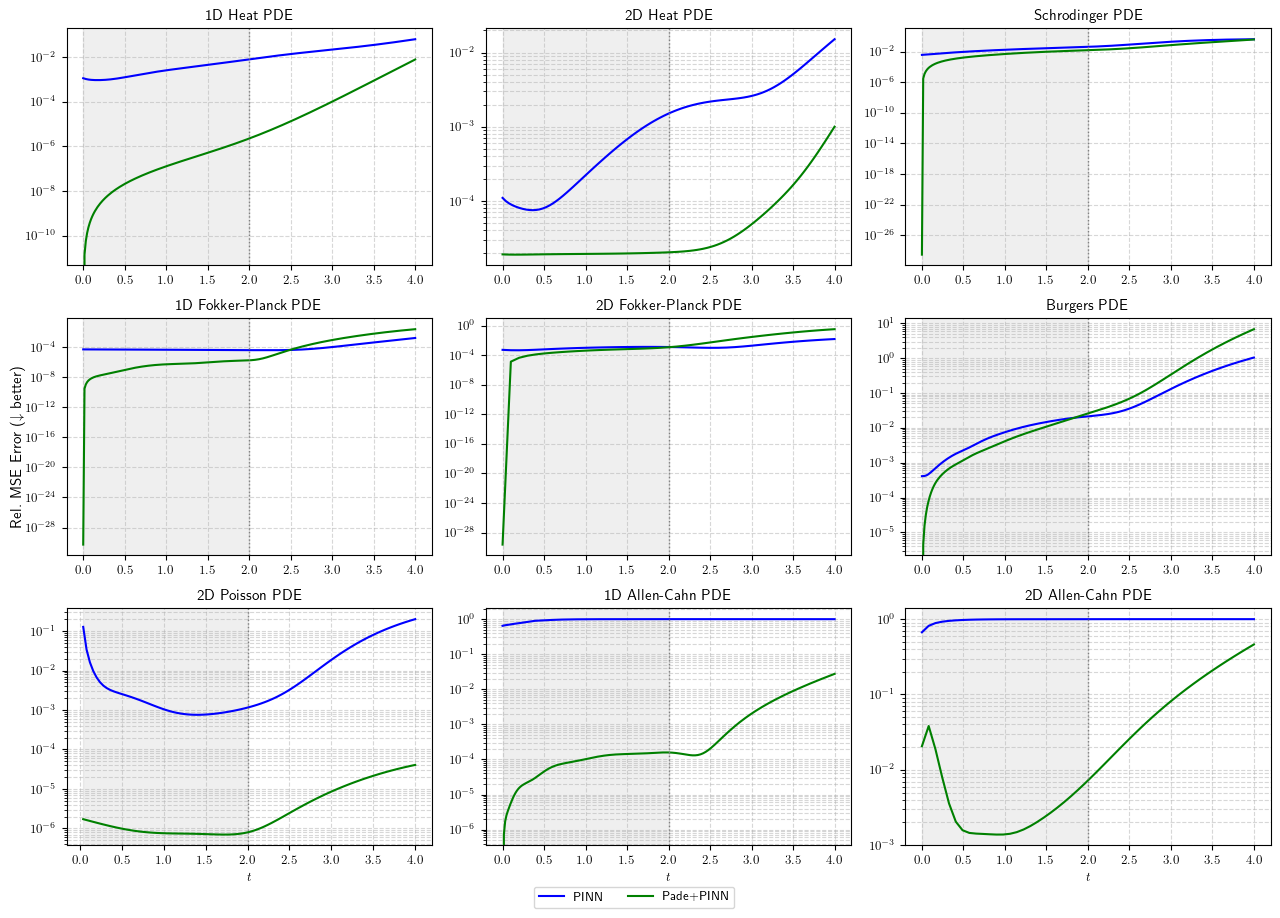

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))

# Rel. MSE error vs t, extended to 2x the training horizon. Shaded band + dotted line mark where training data ends (t=duration) -- everything past it is pure extrapolation.
for ax, (type_, cfg) in zip(axes.flat, pde_configs_all.items()):
    d = extrap_data[type_]
    ax.axvspan(d['t_plot'][0], d['duration'], color='gray', alpha=0.12, zorder=0)
    ax.semilogy(d['t_plot'], d['l2_pinn'] ** 2, color='blue', linewidth=1.5, label='PINN')
    ax.semilogy(d['t_plot'], d['l2_pade_pinn'] ** 2, color='green', linewidth=1.5, label='Pade+PINN')
    ax.axvline(d['duration'], color='gray', linestyle=':', linewidth=1)

    if type_ == 'fokkerplanck2d':  # (theta, kappa) pair instead of a single param
        theta_val, kappa_val = d['param']
        param_str = fr'$\theta={theta_val:.3f},\ \kappa={kappa_val:.3f}$'
    else:
        param_str = fr'$\kappa={d["param"]:.3f}$'
    ax.set_title(fr'{cfg["title"]}')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

for ax in axes[-1]:
    ax.set_xlabel(r'$t$')

fig.supylabel(r'Rel. MSE Error ($\downarrow$ better)')

handles = [plt.Line2D([0], [0], color='blue', lw=1.5), plt.Line2D([0], [0], color='green', lw=1.5)]
fig.legend(handles, ["PINN", "Pade+PINN"], loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02), frameon=True)
plt.tight_layout()
plt.savefig('./figs/error/extrapolation_horizon_comparison.pdf', dpi=800, bbox_inches='tight')
plt.show()

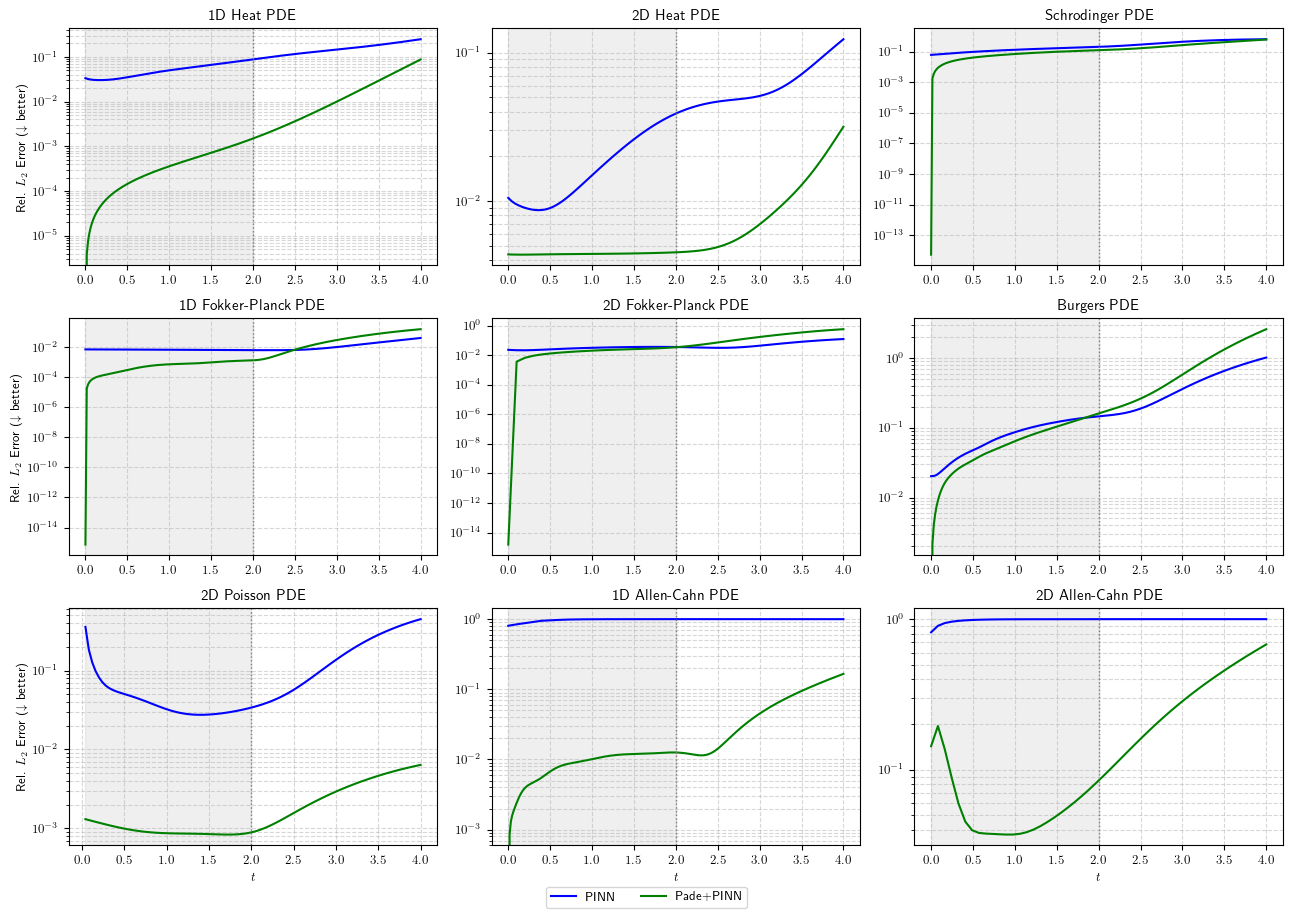

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))

# Rel. L2 error vs t, extended to 2x the training horizon -- same setup as the MSE figure above.
# extrap_data's l2_pinn/l2_pade_pinn are already the raw relative L2 (the MSE plot just squares them).
for ax, (type_, cfg) in zip(axes.flat, pde_configs_all.items()):
    d = extrap_data[type_]
    ax.axvspan(d['t_plot'][0], d['duration'], color='gray', alpha=0.12, zorder=0)
    ax.semilogy(d['t_plot'], d['l2_pinn'], color='blue', linewidth=1.5, label='PINN')
    ax.semilogy(d['t_plot'], d['l2_pade_pinn'], color='green', linewidth=1.5, label='Pade+PINN')
    ax.axvline(d['duration'], color='gray', linestyle=':', linewidth=1)
    ax.set_title(fr'{cfg["title"]}')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

for ax in axes[-1]:
    ax.set_xlabel(r'$t$')

for row in axes:
    row[0].set_ylabel(r'Rel. $L_2$ Error ($\downarrow$ better)')

handles = [plt.Line2D([0], [0], color='blue', lw=1.5), plt.Line2D([0], [0], color='green', lw=1.5)]
fig.legend(handles, ["PINN", "Pade+PINN"], loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02), frameon=True)
plt.tight_layout()
plt.savefig('./figs/error/extrapolation_horizon_l2_comparison.pdf', dpi=800, bbox_inches='tight')
plt.show()